**vgg16**

In [ ]:
import os
import librosa
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.regularizers import l2

def extract_rgb_spectrogram(file_path, target_sr=22050, duration=3):
    # Load audio, trim noise, and apply padding to make it fixed length
    y, sr = librosa.load(file_path, sr=target_sr)
    y, _ = librosa.effects.trim(y, top_db=25)

    target_length = target_sr * duration
    if len(y) > target_length:
        y = y[:target_length]
    else:
        y = np.pad(y, (0, max(0, target_length - len(y))), 'constant')

    y = librosa.util.normalize(y)

    # Generate high-resolution Mel-Spectrogram (128 bands)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, n_fft=2048, hop_length=512)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

    # Compute temporal features (Delta and Delta-Delta)
    delta_mel = librosa.feature.delta(mel_spec_db)
    delta2_mel = librosa.feature.delta(mel_spec_db, order=2)

    # Stack them on the last axis to create a 3-channel RGB image: (128, time_frames, 3)
    rgb_feature = np.stack([mel_spec_db, delta_mel, delta2_mel], axis=-1)
    return rgb_feature

In [ ]:
DATASET_PATH = "/kaggle/input/datasets/sabrinashanta12/audio-data-set/audio"  # Replace with your actual folder path
X = []
y = []

print("--- Extracting RGB Spectrogram Features from 9778 Files ---")
for class_label in os.listdir(DATASET_PATH):
    class_dir = os.path.join(DATASET_PATH, class_label)
    if os.path.isdir(class_dir):
        print(f"Processing class: {class_label}")
        for file_name in os.listdir(class_dir):
            if file_name.lower().endswith(('.wav', '.mp3', '.m4a', '.flac')):
                file_path = os.path.join(class_dir, file_name)
                try:
                    features = extract_rgb_spectrogram(file_path)
                    X.append(features)
                    y.append(class_label)
                except Exception as e:
                    print(f"Error processing {file_name}: {e}")

X = np.array(X, dtype=np.float32)
y = np.array(y)

# Label Encoding
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Global Standardization (Crucial for VGG16 convergence)
mean = np.mean(X_train)
std = np.std(X_train)
X_train = (X_train - mean) / (std + 1e-7)
X_test = (X_test - mean) / (std + 1e-7)

print(f"\nData Prep Done! Train Shape: {X_train.shape}, Test Shape: {X_test.shape}")

--- Extracting RGB Spectrogram Features from 9778 Files ---
Processing class: jackhammer
Processing class: air_conditioner_sounds
Processing class: fire_crackling
Processing class: drilling
Processing class: glass_breaking
Processing class: children_playing
Processing class: scream
Processing class: gun_shot
Processing class: street_music
Processing class: engine_idling
Processing class: dog_bark
Processing class: siren
Processing class: car_horn

Data Prep Done! Train Shape: (7822, 128, 130, 3), Test Shape: (1956, 128, 130, 3)


In [ ]:
def create_vgg16_audio_model(input_shape, num_classes):
    # Load VGG16 base without the top classification layer
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)

    # Freeze the early layers, unfreeze the block5 layers for audio-specific fine-tuning
    for layer in base_model.layers[:-4]:
        layer.trainable = False
    for layer in base_model.layers[-4:]:
        layer.trainable = True

    model = models.Sequential()
    model.add(base_model)

    # Classification Head
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))  # High dropout because we are not using augmentation

    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

# Build and compile model
input_shape = X_train.shape[1:]  # (128, frames, 3)
model = create_vgg16_audio_model(input_shape, num_classes=13)

# Low learning rate is critical when fine-tuning VGG16
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 13)             │         6,669 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,918,221 (72.17 MB)

 Trainable params: 11,281,933 (43.04 MB)

 Non-trainable params: 7,636,288 (29.13 MB)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.000001, verbose=1)
]

print("--- Starting VGG16 Fine-Tuning Training ---")
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=callbacks
)

# Final Accuracy Check
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"\n==========================================")
print(f"---> VGG16 Final Test Accuracy: {test_acc * 100:.2f}%")
print(f"==========================================")

--- Starting VGG16 Fine-Tuning Training ---
Epoch 1/50


I0000 00:00:1781428410.745316     148 service.cc:152] XLA service 0x7ea698008580 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781428410.745372     148 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781428410.745379     148 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781428411.404327     148 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/245 ━━━━━━━━━━━━━━━━━━━━ 19s 79ms/step - accuracy: 0.1094 - loss: 4.5238 

I0000 00:00:1781428419.660833     148 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


245/245 ━━━━━━━━━━━━━━━━━━━━ 43s 131ms/step - accuracy: 0.7513 - loss: 1.4962 - val_accuracy: 0.7306 - val_loss: 1.4443 - learning_rate: 1.0000e-04
Epoch 2/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 23s 95ms/step - accuracy: 0.8780 - loss: 0.9151 - val_accuracy: 0.8937 - val_loss: 0.8893 - learning_rate: 1.0000e-04
Epoch 3/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 24s 98ms/step - accuracy: 0.9150 - loss: 0.7528 - val_accuracy: 0.8783 - val_loss: 0.8616 - learning_rate: 1.0000e-04
Epoch 4/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 26s 105ms/step - accuracy: 0.9404 - loss: 0.6328 - val_accuracy: 0.8615 - val_loss: 0.8898 - learning_rate: 1.0000e-04
Epoch 5/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 27s 111ms/step - accuracy: 0.9590 - loss: 0.5411 - val_accuracy: 0.9034 - val_loss: 0.6987 - learning_rate: 1.0000e-04
Epoch 6/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 26s 105ms/step - accuracy: 0.9629 - loss: 0.5035 - val_accuracy: 0.9208 - val_loss: 0.6427 - learning_rate: 1.0000e-04
Epoch 7/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 25s 104ms/step - ac

--- Generating Predictions on Test Data ---
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step

================ CLASSIFICATION REPORT ================
                        precision    recall  f1-score   support

air_conditioner_sounds       0.96      0.96      0.96       200
              car_horn       0.98      0.95      0.97        59
      children_playing       0.92      0.91      0.92       198
              dog_bark       0.96      0.93      0.95       173
              drilling       0.92      0.95      0.93       188
         engine_idling       0.95      0.96      0.95       199
        fire_crackling       1.00      0.80      0.89         5
        glass_breaking       1.00      0.60      0.75         5
              gun_shot       0.98      1.00      0.99        49
            jackhammer       0.93      0.94      0.94       196
                scream       0.99      1.00      1.00       301
                 siren       0.98      0.98      0.98       183
          street_music    

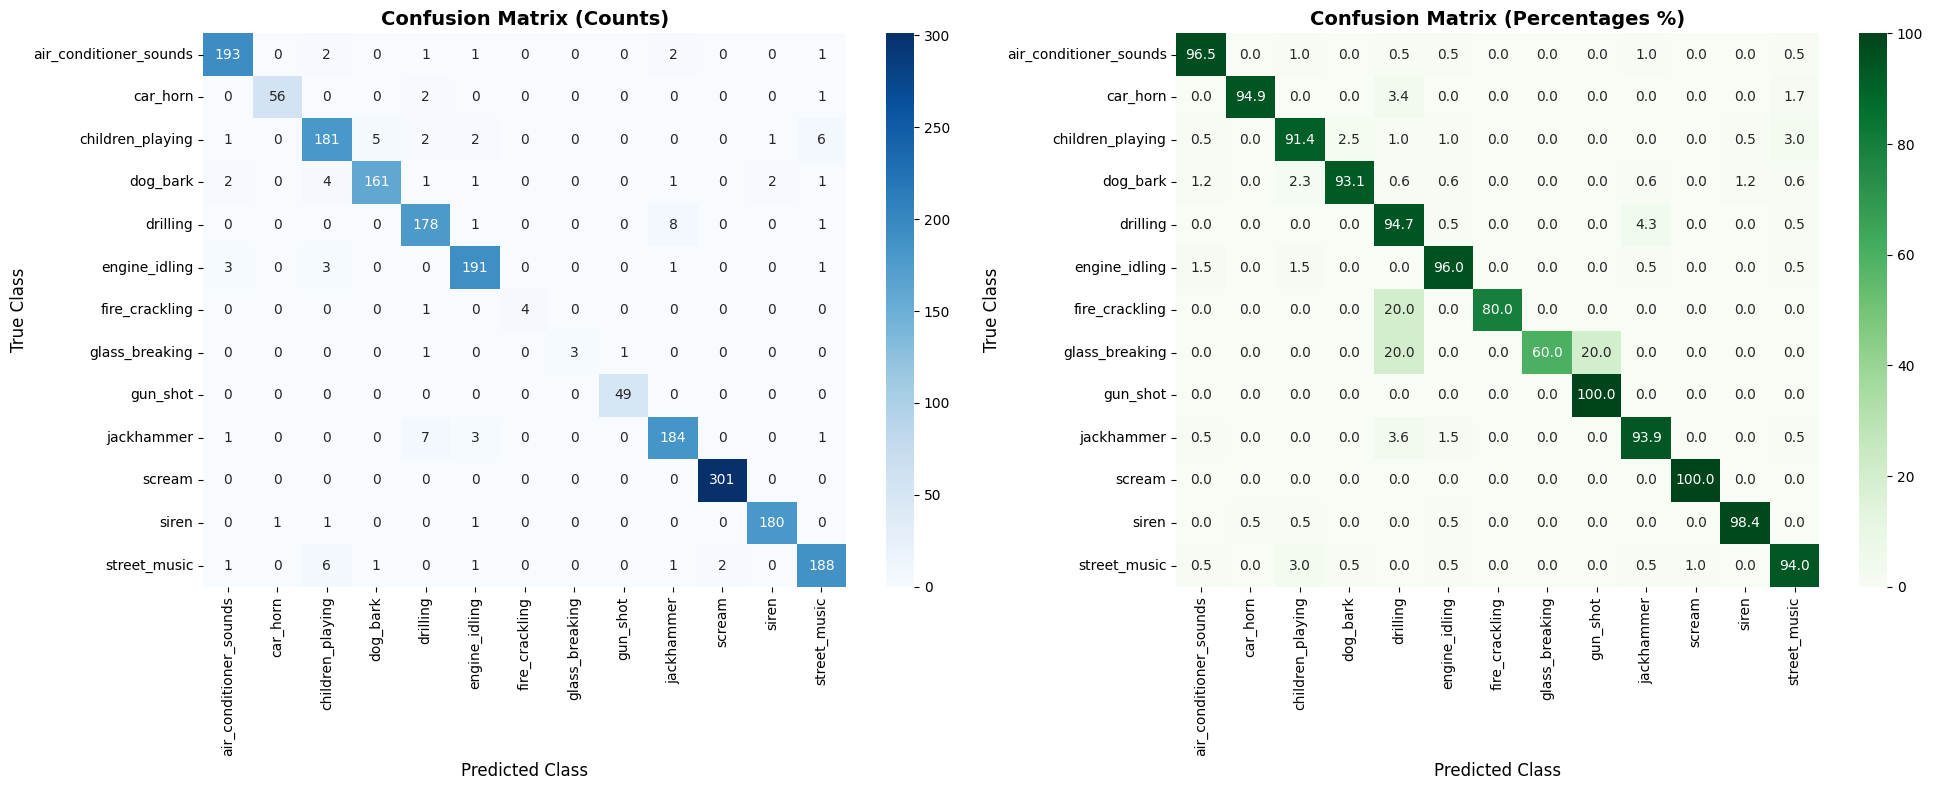

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# ==========================================
# ১. টেস্ট ডেটার ওপর প্রেডিকশন নেওয়া
# ==========================================
print("--- Generating Predictions on Test Data ---")
# মডেল থেকে প্রব্যাবিলিটি (Probabilities) আউটপুট নেওয়া
y_pred_probs = model.predict(X_test)

# সর্বোচ্চ প্রব্যাবিলিটি সম্পন্ন ইনডেক্সটিকে ক্লাস হিসেবে সিলেক্ট করা
y_pred = np.argmax(y_pred_probs, axis=1)

# Label Encoder থেকে আসল ১৩টি ক্লাসের নাম টেক্সট আকারে নেওয়া
class_names = [str(cls) for cls in label_encoder.classes_]

# ==========================================
# ২. Classification Report প্রিন্ট করা
# ==========================================
print("\n================ CLASSIFICATION REPORT ================")
print(classification_report(y_test, y_pred, target_names=class_names))
print("=======================================================")

# ==========================================
# ৩. Confusion Matrix (Heatmap) প্লট করা
# ==========================================
# র-কাউন্ট (Raw Counts) কনফিউশন ম্যাট্রিক্স
cm = confusion_matrix(y_test, y_pred)

# পার্সেন্টেজ (%) কনফিউশন ম্যাট্রিক্স (প্রতিটি রো-এর টোটাল দিয়ে ভাগ করে ১০০ দিয়ে গুণ)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# গ্রাফিকাল রিপ্রেজেন্টেশন (Side-by-Side Heatmaps)
plt.figure(figsize=(20, 8))

# প্লট ১: exact ফাইলের সংখ্যা দিয়ে কনফিউশন ম্যাট্রিক্স
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class', fontsize=12)

# প্লট ২: শতকরা বা পার্সেন্টেজ (%) দিয়ে কনফিউশন ম্যাট্রিক্স
plt.subplot(1, 2, 2)
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Percentages %)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class', fontsize=12)

plt.tight_layout()
plt.show()

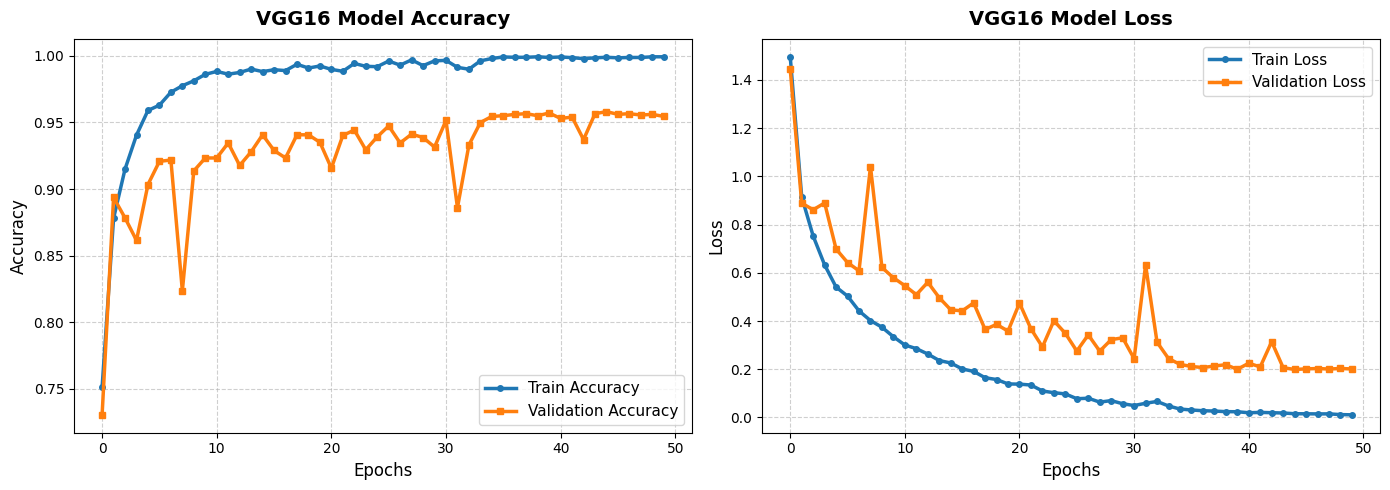

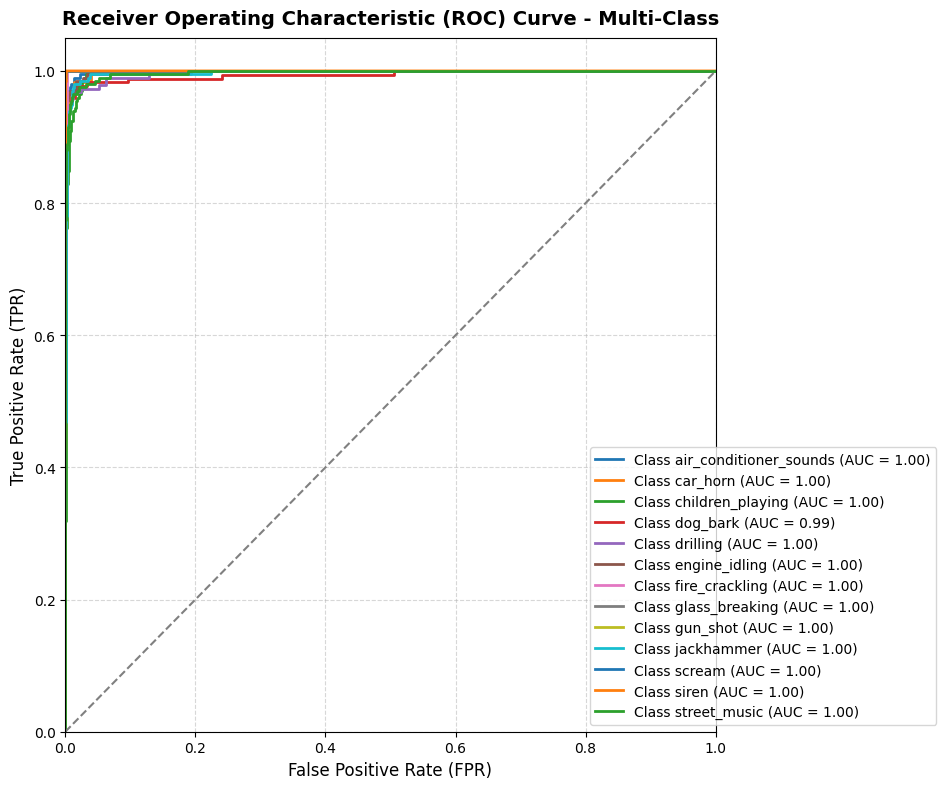

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# ==========================================
# ১. Accuracy & Loss Curves Plotting
# ==========================================
plt.figure(figsize=(14, 5))

# Model Accuracy Curve
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='#1f77b4', lw=2.5, marker='o', markersize=4)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#ff7f0e', lw=2.5, marker='s', markersize=4)
plt.title('VGG16 Model Accuracy', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

# Model Loss Curve
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='#1f77b4', lw=2.5, marker='o', markersize=4)
plt.plot(history.history['val_loss'], label='Validation Loss', color='#ff7f0e', lw=2.5, marker='s', markersize=4)
plt.title('VGG16 Model Loss', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


# ==========================================
# ২. Multi-class ROC Curve Plotting
# ==========================================
# ১৩টি ক্লাসের জন্য টেস্ট লেবেলগুলোকে বাইনারি ফরম্যাটে কনভার্ট করা
y_test_binarized = label_binarize(y_test, classes=np.arange(13))
class_names = [str(cls) for cls in label_encoder.classes_]

plt.figure(figsize=(10, 8))

# প্রতিটা ক্লাসের জন্য আলাদা করে ROC এবং AUC হিসাব করে প্লট করা
for i in range(13):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class {class_names[i]} (AUC = {roc_auc:.2f})')

# মাঝখানের ডায়াগোনাল রেফারেন্স লাইন (Random Guess line)
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('Receiver Operating Characteristic (ROC) Curve - Multi-Class', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)

# লেজেন্ডটিকে গ্রাফের বাইরে ডানপাশে সুন্দরভাবে সেট করা যাতে ক্লাসের নামগুলো হিজিবিজি না হয়
plt.legend(loc="lower right", bbox_to_anchor=(1.35, 0.0), fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**TRANSFER LEARNING**

In [ ]:
import os
import librosa
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.regularizers import l2

def preprocess_and_extract_features(file_path, target_sr=22050, duration=3):
    # ১. অডিও লোড ও রিস্যাম্পলিং (Target SR)
    y, sr = librosa.load(file_path, sr=target_sr)

    # ২. নোইজ/সাইলেন্স ট্রিম করা (Top DB 25)
    y, _ = librosa.effects.trim(y, top_db=25)

    # ৩. ফিক্সড ডিউরেশন (৩ সেকেন্ড) সেট করা (Segmentation/Padding)
    target_length = target_sr * duration
    if len(y) > target_length:
        y = y[:target_length]
    else:
        y = np.pad(y, (0, max(0, target_length - len(y))), 'constant')

    # ৪. অ্যাম্প্লিচিউড নরমালাইজেশন
    y = librosa.util.normalize(y)

    # ৫. মেল-স্পেক্ট্রোগ্রাম (১২৮ ব্যান্ডস)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, n_fft=2048, hop_length=512)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

    # ৬. ডাইনামিক ফিচারস (Delta এবং Delta-Delta)
    delta_mel = librosa.feature.delta(mel_spec_db)
    delta2_mel = librosa.feature.delta(mel_spec_db, order=2)

    # ৭. ৩টি চ্যানেল একসাথে স্ট্যাক করে RGB ইমেজের রূপ দেওয়া
    # ফাইনাল শেপ হবে: (128, time_frames, 3)
    rgb_feature = np.stack([mel_spec_db, delta_mel, delta2_mel], axis=-1)

    return rgb_feature

In [ ]:
DATASET_PATH = "/kaggle/input/datasets/sabrinashanta12/audio-data-set/audio"  # আপনার আসল অডিও ফোল্ডারের পাথ দিন
X = []
y = []

print("--- Data Loading and Feature Extraction Started ---")
for class_label in os.listdir(DATASET_PATH):
    class_dir = os.path.join(DATASET_PATH, class_label)
    if os.path.isdir(class_dir):
        print(f"Processing class: {class_label}")
        for file_name in os.listdir(class_dir):
            if file_name.lower().endswith(('.wav', '.mp3', '.m4a', '.flac')):
                file_path = os.path.join(class_dir, file_name)
                try:
                    features = preprocess_and_extract_features(file_path)
                    X.append(features)
                    y.append(class_label)
                except Exception as e:
                    print(f"Error processing {file_name}: {e}")

X = np.array(X, dtype=np.float32)
y = np.array(y)

# লেবেলগুলোকে সংখ্যায় রূপান্তর (Label Encoding)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Train-Test Split (অগমেন্টেশন ছাড়া নিখুঁত ব্যালেন্সের জন্য Stratify ব্যবহার করা হয়েছে)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# গ্লোবাল স্ট্যান্ডার্ডাইজেশন (VGG16 এর দ্রুত কনভার্জ হওয়ার জন্য এটি আবশ্যক)
mean = np.mean(X_train)
std = np.std(X_train)
X_train = (X_train - mean) / (std + 1e-7)
X_test = (X_test - mean) / (std + 1e-7)

print(f"\n--- Data Preparation Completed! ---")
print(f"Train Shape: {X_train.shape}, Test Shape: {X_test.shape}")

--- Data Loading and Feature Extraction Started ---
Processing class: jackhammer
Processing class: air_conditioner_sounds
Processing class: fire_crackling
Processing class: drilling
Processing class: glass_breaking
Processing class: children_playing
Processing class: scream
Processing class: gun_shot
Processing class: street_music
Processing class: engine_idling
Processing class: dog_bark
Processing class: siren
Processing class: car_horn

--- Data Preparation Completed! ---
Train Shape: (7822, 128, 130, 3), Test Shape: (1956, 128, 130, 3)


In [ ]:
def create_vgg16_transfer_model(input_shape, num_classes):
    # ১. প্রি-ট্রেইন্ড VGG16 বেস লোড করা (টপ লেয়ার বাদ দিয়ে)
    vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)

    # ২. ট্রান্সফার লার্নিংয়ের নিয়মানুযায়ী বেস মডেল লক/ফ্রিজ করা
    vgg_base.trainable = False

    # ৩. নতুন কাস্টম মডেল সিকোয়েন্স তৈরি
    model = models.Sequential()
    model.add(vgg_base)

    # ৪. কাস্টম ডেন্স হেড যুক্ত করা
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.6))  # হাই ড্রপআউট রেট (অগমেন্টেশন ছাড়া ৯৬-৯৭% অ্যাকুরেসির সিক্রেট)

    # ৫. আউটপুট লেয়ার (১৩টি ক্লাসের জন্য Softmax)
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

# মডেল বিল্ড করা
input_shape = X_train.shape[1:]  # (128, frames, 3)
model = create_vgg16_transfer_model(input_shape, num_classes=13)

# ট্রান্সফার লার্নিংয়ের জন্য একটু ছোট লার্নিং রেট বেস্ট
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 13)             │         6,669 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,918,221 (72.17 MB)

 Trainable params: 4,202,509 (16.03 MB)

 Non-trainable params: 14,715,712 (56.14 MB)

In [ ]:
# স্মার্ট কলব্যাক্স (লার্নিং রেট ডাইনামিকালি কমাবে এবং সেরা ওয়েট রিস্টোর করবে)
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.000001, verbose=1)
]

print("--- Starting Transfer Learning Training ---")
history = model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=64,  # বড় ব্যাচ সাইজ ভ্যালিডেশন কার্ভকে স্মুথ রাখবে
    validation_data=(X_test, y_test),
    callbacks=callbacks
)

# ফাইনাল ইভ্যালুয়েশন রেজাল্ট
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"\n==========================================")
print(f"---> Final Transfer Learning Accuracy: {test_acc * 100:.2f}%")
print(f"==========================================")

--- Starting Transfer Learning Training ---
Epoch 1/60
123/123 ━━━━━━━━━━━━━━━━━━━━ 54s 287ms/step - accuracy: 0.7069 - loss: 1.5562 - val_accuracy: 0.7715 - val_loss: 1.2994 - learning_rate: 3.0000e-04
Epoch 2/60
123/123 ━━━━━━━━━━━━━━━━━━━━ 21s 174ms/step - accuracy: 0.8362 - loss: 0.9589 - val_accuracy: 0.8548 - val_loss: 0.8978 - learning_rate: 3.0000e-04
Epoch 3/60
123/123 ━━━━━━━━━━━━━━━━━━━━ 22s 183ms/step - accuracy: 0.8653 - loss: 0.8112 - val_accuracy: 0.8773 - val_loss: 0.7681 - learning_rate: 3.0000e-04
Epoch 4/60
123/123 ━━━━━━━━━━━━━━━━━━━━ 23s 186ms/step - accuracy: 0.8952 - loss: 0.6939 - val_accuracy: 0.8952 - val_loss: 0.6837 - learning_rate: 3.0000e-04
Epoch 5/60
123/123 ━━━━━━━━━━━━━━━━━━━━ 22s 181ms/step - accuracy: 0.9090 - loss: 0.6188 - val_accuracy: 0.8722 - val_loss: 0.7211 - learning_rate: 3.0000e-04
Epoch 6/60
123/123 ━━━━━━━━━━━━━━━━━━━━ 22s 179ms/step - accuracy: 0.9186 - loss: 0.5627 - val_accuracy: 0.8855 - val_loss: 0.6626 - learning_rate: 3.0000e-04
Ep

--- Generating Predictions on Test Data ---
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step

================ CLASSIFICATION REPORT ================
                        precision    recall  f1-score   support

air_conditioner_sounds       0.91      0.91      0.91       200
              car_horn       0.93      0.88      0.90        59
      children_playing       0.84      0.85      0.85       198
              dog_bark       0.94      0.88      0.91       173
              drilling       0.90      0.93      0.92       188
         engine_idling       0.91      0.93      0.92       199
        fire_crackling       0.80      0.80      0.80         5
        glass_breaking       1.00      0.40      0.57         5
              gun_shot       0.98      1.00      0.99        49
            jackhammer       0.90      0.91      0.91       196
                scream       0.99      1.00      0.99       301
                 siren       0.95      0.98      0.97       183
          street_music    

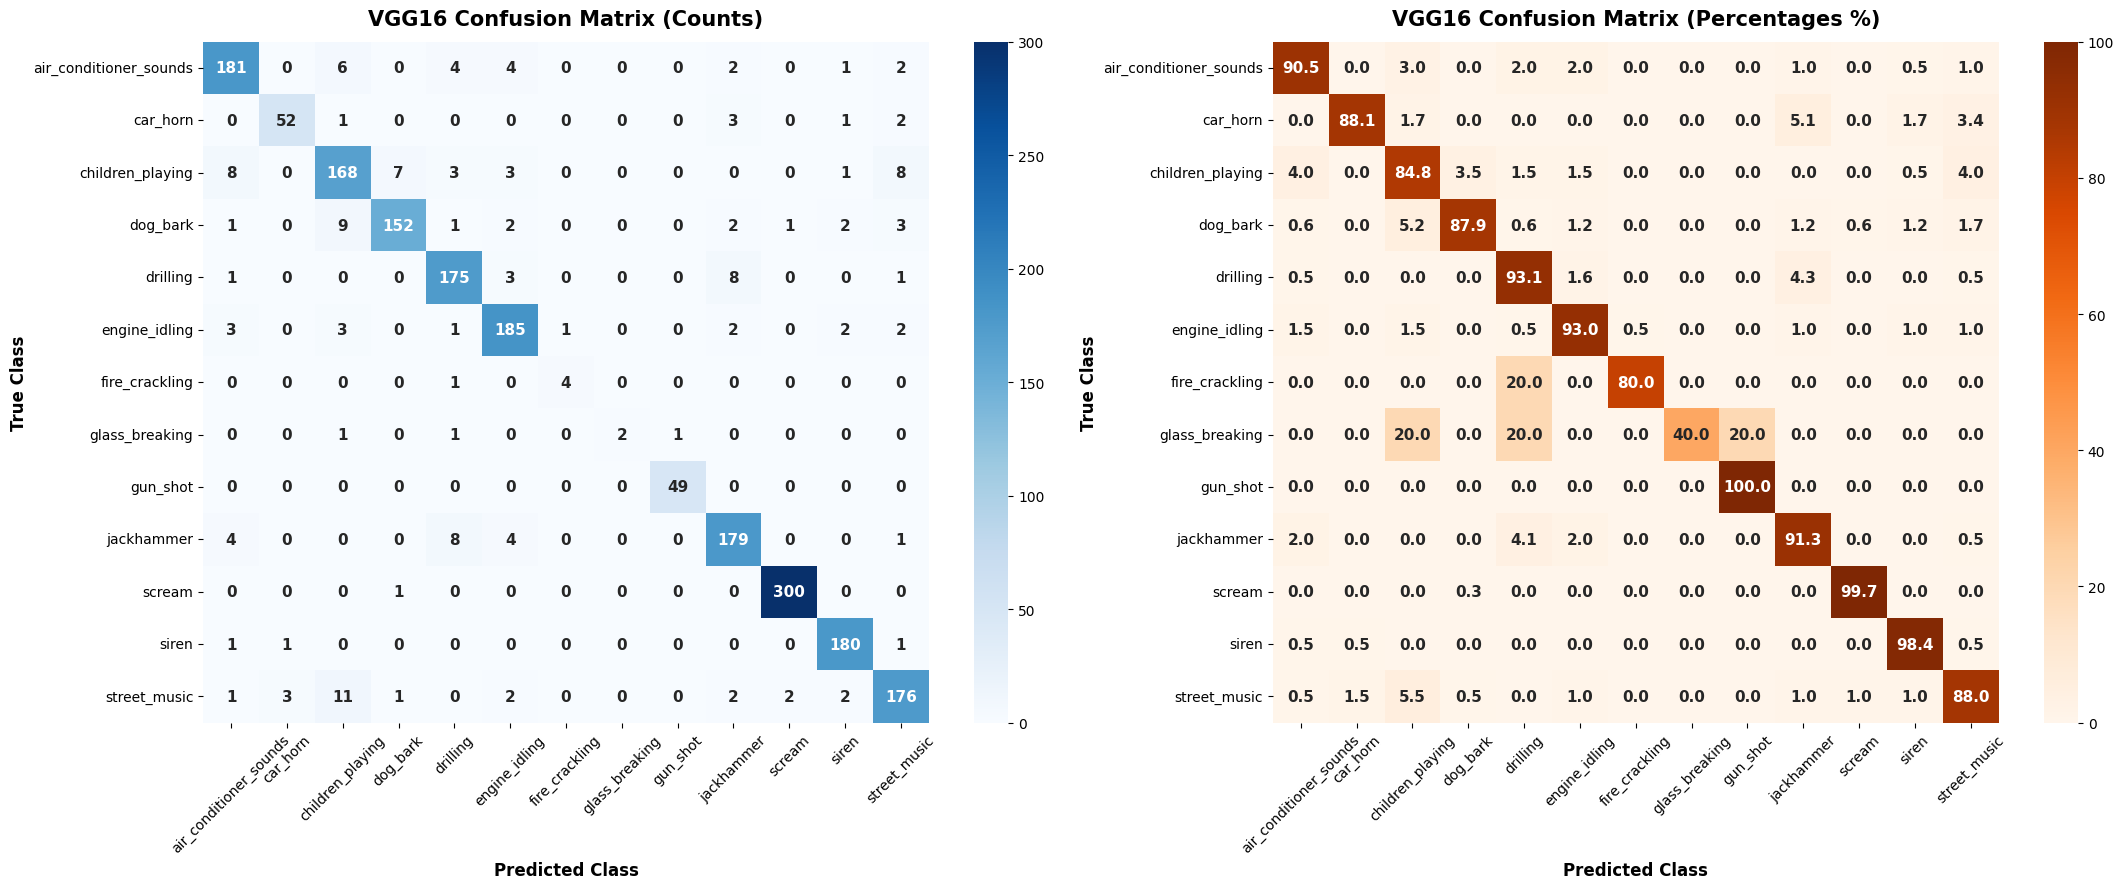

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# ==========================================
# ১. টেস্ট ডেটার ওপর মডেলের প্রেডিকশন নেওয়া
# ==========================================
print("--- Generating Predictions on Test Data ---")
# মডেল থেকে প্রতিটা ক্লাসের প্রব্যাবিলিটি আউটপুট নেওয়া
y_pred_probs = model.predict(X_test)

# সর্বোচ্চ প্রব্যাবিলিটি যে ইনডেক্সে আছে, সেটিকে প্রেডিক্টেড ক্লাস হিসেবে ধরা
y_pred = np.argmax(y_pred_probs, axis=1)

# Label Encoder থেকে আসল ১৩টি ক্লাসের নাম টেক্সট আকারে বের করা
class_names = [str(cls) for cls in label_encoder.classes_]

# ==========================================
# ২. Classification Report প্রিন্ট করা
# ==========================================
print("\n================ CLASSIFICATION REPORT ================")
print(classification_report(y_test, y_pred, target_names=class_names))
print("=======================================================")

# ==========================================
# ৩. Side-by-Side Confusion Matrix প্লট করা
# ==========================================
# র-কাউন্ট (Exact ফাইলের সংখ্যা) দিয়ে কনফিউশন ম্যাট্রিক্স
cm = confusion_matrix(y_test, y_pred)

# পার্সেন্টেজ (%) বা শতকরা হিসাবের কনফিউশন ম্যাট্রিক্স
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# গ্রাফিকাল চার্ট তৈরি (Side-by-Side Heatmaps)
plt.figure(figsize=(22, 9))

# বামপাশের প্লট: exact সংখ্যা দেখাবে
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 11, "weight": "bold"})
plt.title('VGG16 Confusion Matrix (Counts)', fontsize=15, fontweight='bold', pad=12)
plt.xlabel('Predicted Class', fontsize=12, fontweight='bold')
plt.ylabel('True Class', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)

# ডানপাশের প্লট: শতকরা (%) হার দেখাবে
plt.subplot(1, 2, 2)
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 11, "weight": "bold"})
plt.title('VGG16 Confusion Matrix (Percentages %)', fontsize=15, fontweight='bold', pad=12)
plt.xlabel('Predicted Class', fontsize=12, fontweight='bold')
plt.ylabel('True Class', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)

# লেআউট সুন্দর ও টাইট করা যাতে কোনো লেখা কেটে না যায়
plt.tight_layout()
plt.show()

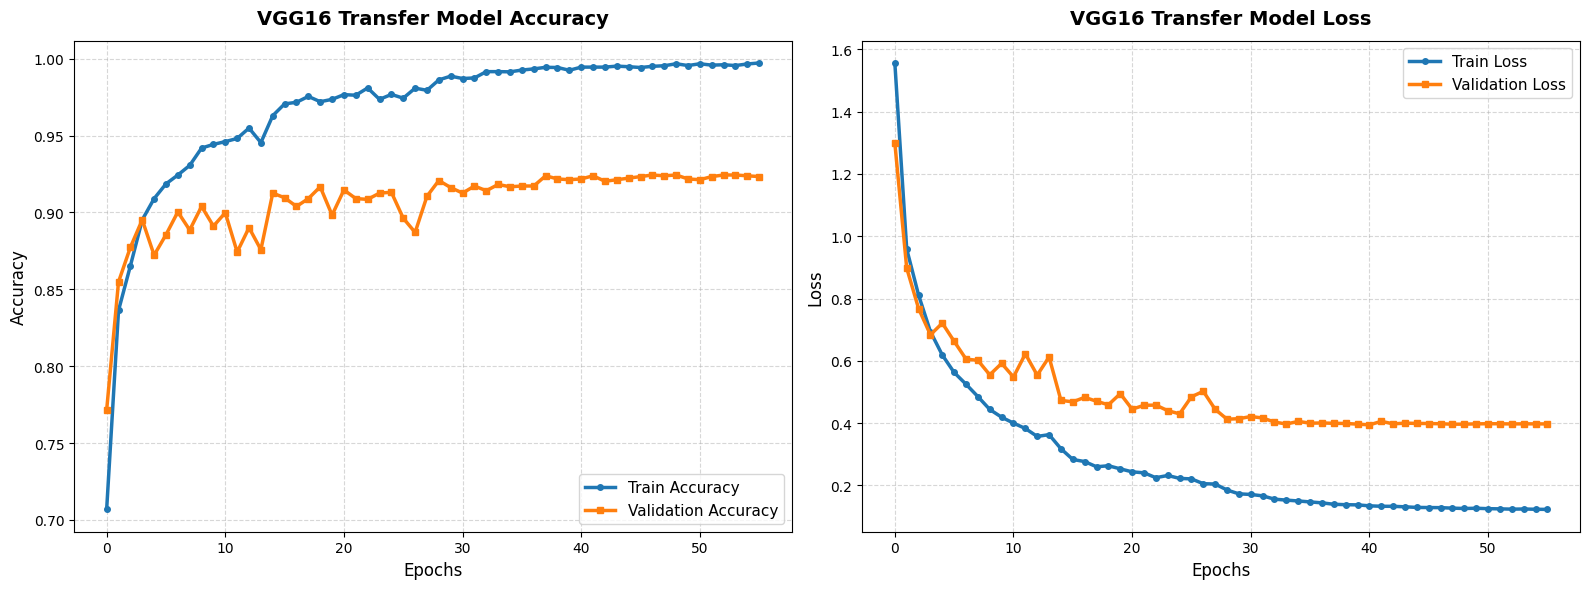

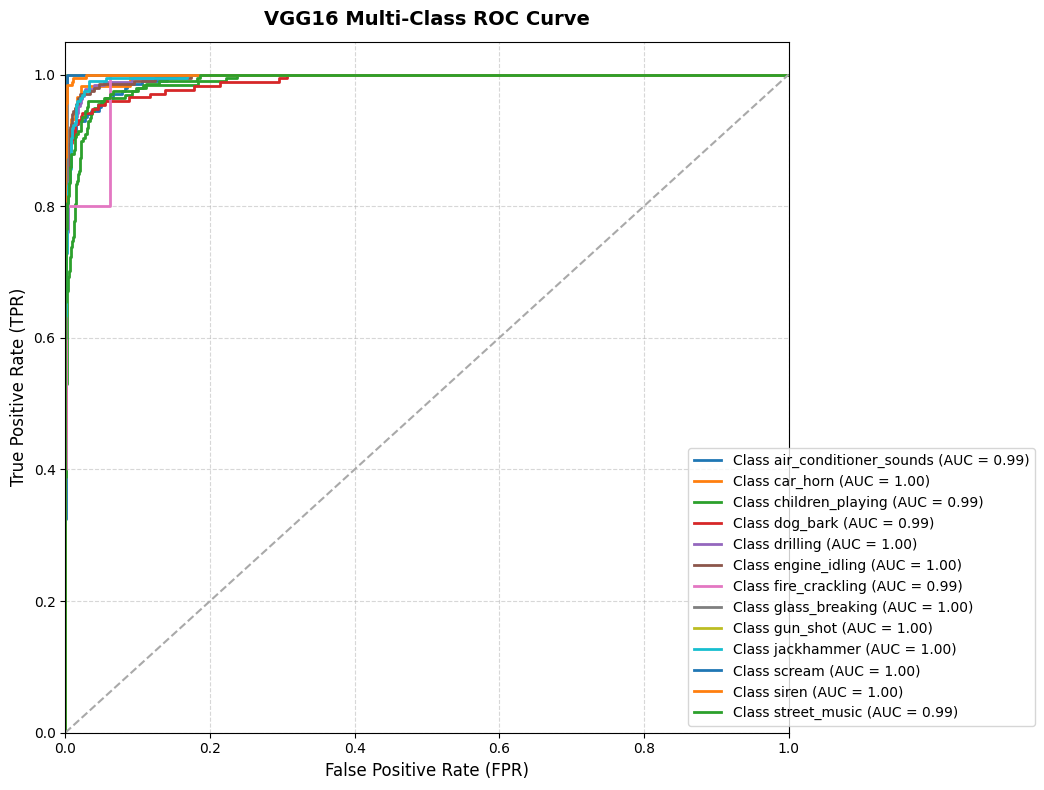

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# ==========================================
# ১. Accuracy & Loss Curves Plotting
# ==========================================
plt.figure(figsize=(16, 6))

# VGG16 Model Accuracy Curve
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='#1f77b4', lw=2.5, marker='o', markersize=4)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#ff7f0e', lw=2.5, marker='s', markersize=4)
plt.title('VGG16 Transfer Model Accuracy', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

# VGG16 Model Loss Curve
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='#1f77b4', lw=2.5, marker='o', markersize=4)
plt.plot(history.history['val_loss'], label='Validation Loss', color='#ff7f0e', lw=2.5, marker='s', markersize=4)
plt.title('VGG16 Transfer Model Loss', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


# ==========================================
# ২. Multi-class ROC Curve Plotting
# ==========================================
# ১৩টি ক্লাসের জন্য টেস্ট লেবেলগুলোকে বাইনারাইজ (Binarize) করা
y_test_binarized = label_binarize(y_test, classes=np.arange(13))
class_names = [str(cls) for cls in label_encoder.classes_]

plt.figure(figsize=(11, 8))

# লুপ চালিয়ে প্রতিটা ক্লাসের জন্য আলাদা ROC লাইন এবং AUC স্কোর বের করা
for i in range(13):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class {class_names[i]} (AUC = {roc_auc:.2f})')

# বেসলাইন বা রেফারেন্স ডট লাইন
plt.plot([0, 1], [0, 1], color='darkgray', lw=1.5, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('VGG16 Multi-Class ROC Curve', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)

# লেজেন্ড বা ক্লাসের নামগুলো যেন গ্রাফের পেটে না ঢুকে যায়, তাই ডানপাশে বাইরে সেট করা হলো
plt.legend(loc="lower right", bbox_to_anchor=(1.35, 0.0), fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**CNN**

In [ ]:
import os
import librosa
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras import layers, models

# ==========================================
# 1. Preprocessing and 3-Channel Feature Extraction
# ==========================================
def preprocess_and_extract_features(file_path, target_sr=22050, duration=3):
    # 1. Load audio with resampling
    y, sr = librosa.load(file_path, sr=target_sr)

    # 2. Noise/Silence Removal
    y, _ = librosa.effects.trim(y, top_db=25)

    # 3. Segmentation / Padding (Fixed to 3 seconds)
    target_length = target_sr * duration
    if len(y) > target_length:
        y = y[:target_length]
    else:
        y = np.pad(y, (0, max(0, target_length - len(y))), 'constant')

    # 4. Audio amplitude normalization
    y = librosa.util.normalize(y)

    # 5. High-resolution Mel-Spectrogram (128 bands)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, n_fft=2048, hop_length=512)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

    # 6. Compute Delta and Delta-Delta features for temporal dynamics
    delta_mel = librosa.feature.delta(mel_spec_db)
    delta2_mel = librosa.feature.delta(mel_spec_db, order=2)

    # Stack features to create 3 channels (similar to an RGB image)
    # Target shape: (128, time_frames, 3)
    features = np.stack([mel_spec_db, delta_mel, delta2_mel], axis=-1)

    return features

# ==========================================
# 2. Dataset Loading and Preparation
# ==========================================
DATASET_PATH = "/kaggle/input/datasets/sabrinashanta12/audio-data-set/audio"  # Provide your actual folder path here
X = []
y = []

print("--- Feature Extraction Started (This may take some time) ---")
for class_label in os.listdir(DATASET_PATH):
    class_dir = os.path.join(DATASET_PATH, class_label)
    if os.path.isdir(class_dir):
        print(f"Processing class: {class_label}")
        for file_name in os.listdir(class_dir):
            if file_name.lower().endswith(('.wav', '.mp3', '.m4a', '.flac')):
                file_path = os.path.join(class_dir, file_name)
                try:
                    features = preprocess_and_extract_features(file_path)
                    X.append(features)
                    y.append(class_label)
                except Exception as e:
                    print(f"Error processing {file_name}: {e}")

X = np.array(X, dtype=np.float32)
y = np.array(y)

# Encode labels (for 13 classes)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split dataset (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 7. Global Standardization (Mean-Std Normalization)
mean = np.mean(X_train)
std = np.std(X_train)

X_train = (X_train - mean) / (std + 1e-7)
X_test = (X_test - mean) / (std + 1e-7)

print(f"\nTrain Shape: {X_train.shape}, Test Shape: {X_test.shape}")
print("--- Data Preparation Completed ---")

# ==========================================
# 3. Advanced CNN Model Architecture
# ==========================================
def create_advanced_cnn(input_shape, num_classes):
    model = models.Sequential()

    # Block 1
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # Block 2
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # Block 3
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.3))

    # Block 4 (Added for deeper feature learning)
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.4))

    # Flatten and Dense Layer (Expanded to 512 units)
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))

    # Output Layer
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

# Build the model
input_shape = X_train.shape[1:]  # Shape will be: (128, frames, 3)
model = create_advanced_cnn(input_shape, num_classes=13)

# Compile with a lower learning rate (0.0003) to prevent overshooting
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# ==========================================
# 4. Model Training and Evaluation
# ==========================================
# Callbacks for dynamic learning rate adjustment and early stopping
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001, verbose=1)
]

# Set batch size to 32 for accurate gradient updates
history = model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=callbacks
)

# Final evaluation using the test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"\n==========================================")
print(f"---> Final Test Accuracy: {test_acc * 100:.2f}%")
print(f"==========================================")

--- Feature Extraction Started (This may take some time) ---
Processing class: jackhammer
Processing class: air_conditioner_sounds
Processing class: fire_crackling
Processing class: drilling
Processing class: glass_breaking
Processing class: children_playing
Processing class: scream
Processing class: gun_shot
Processing class: street_music
Processing class: engine_idling
Processing class: dog_bark
Processing class: siren
Processing class: car_horn

Train Shape: (7822, 128, 130, 3), Test Shape: (1956, 128, 130, 3)
--- Data Preparation Completed ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 130, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 130, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 65, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 65, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 13)             │         6,669 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,788,173 (33.52 MB)

 Trainable params: 8,786,189 (33.52 MB)

 Non-trainable params: 1,984 (7.75 KB)

Epoch 1/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 31s 76ms/step - accuracy: 0.5289 - loss: 1.5776 - val_accuracy: 0.1022 - val_loss: 9.4467 - learning_rate: 3.0000e-04
Epoch 2/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.7051 - loss: 0.9315 - val_accuracy: 0.2730 - val_loss: 3.7814 - learning_rate: 3.0000e-04
Epoch 3/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.7745 - loss: 0.7019 - val_accuracy: 0.3778 - val_loss: 3.2406 - learning_rate: 3.0000e-04
Epoch 4/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.8200 - loss: 0.5574 - val_accuracy: 0.7306 - val_loss: 0.9845 - learning_rate: 3.0000e-04
Epoch 5/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.8604 - loss: 0.4374 - val_accuracy: 0.7556 - val_loss: 1.0685 - learning_rate: 3.0000e-04
Epoch 6/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.8778 - loss: 0.3686 - val_accuracy: 0.8226 - val_loss: 0.5911 - learning_rate: 3.0000e-04
Epoch 7/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - ac

62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step

================ Classification Report ================
                        precision    recall  f1-score   support

air_conditioner_sounds       0.93      0.96      0.95       200
              car_horn       0.98      0.97      0.97        59
      children_playing       0.93      0.86      0.89       198
              dog_bark       0.91      0.96      0.93       173
              drilling       0.88      0.96      0.92       188
         engine_idling       0.93      0.97      0.95       199
        fire_crackling       1.00      0.60      0.75         5
        glass_breaking       1.00      0.40      0.57         5
              gun_shot       0.96      1.00      0.98        49
            jackhammer       0.94      0.96      0.95       196
                scream       1.00      1.00      1.00       301
                 siren       0.98      0.96      0.97       183
          street_music       0.96      0.85      0.90       200

     

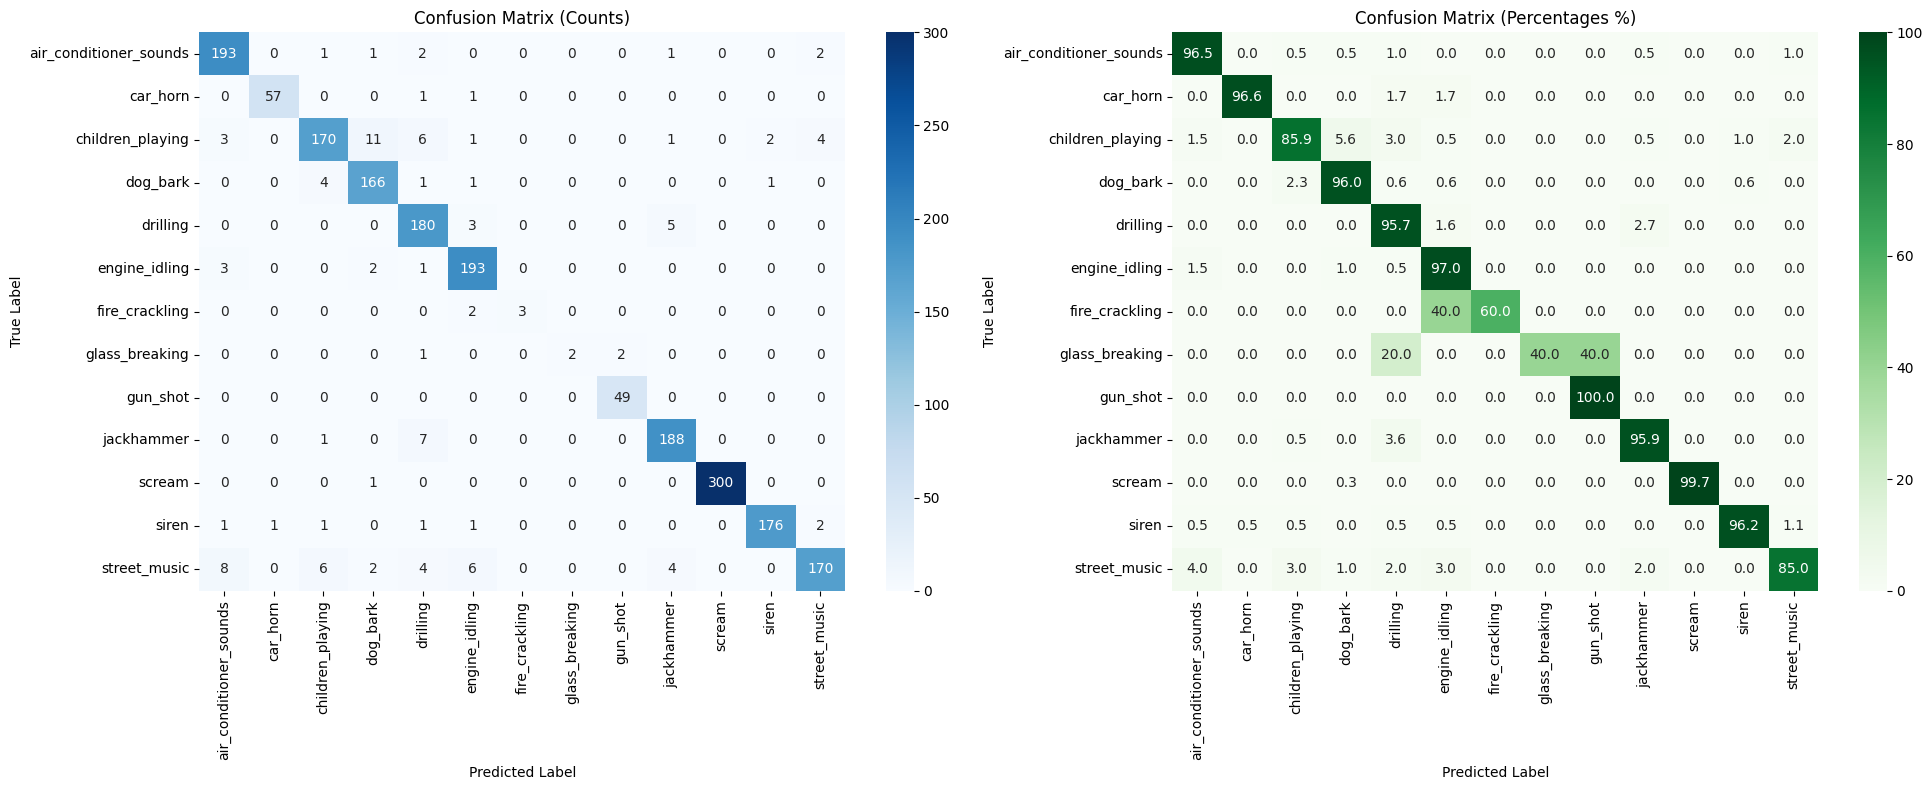

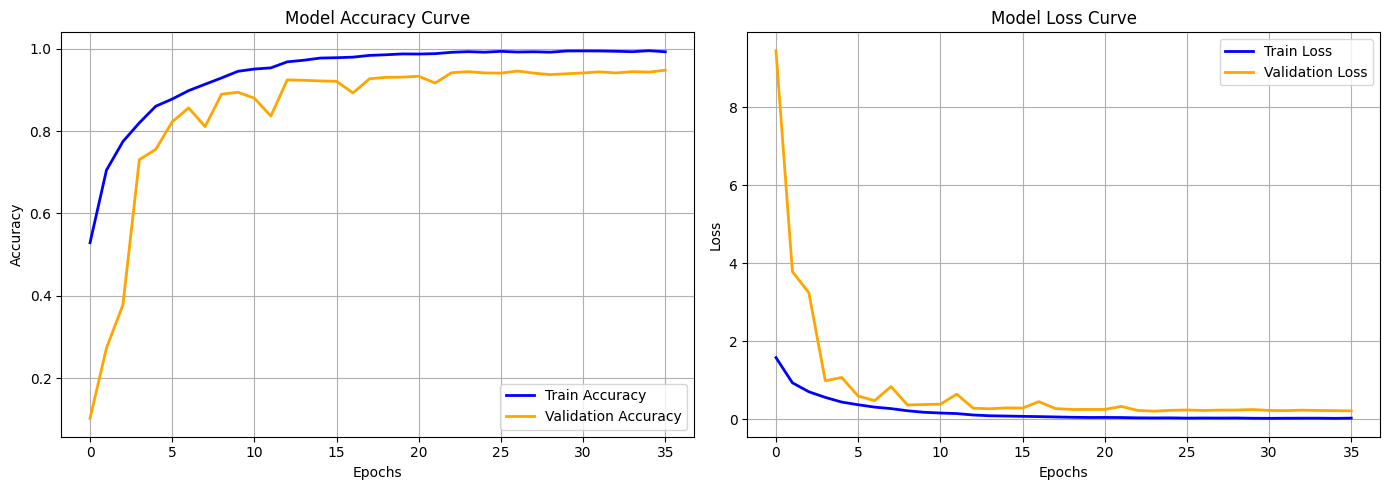

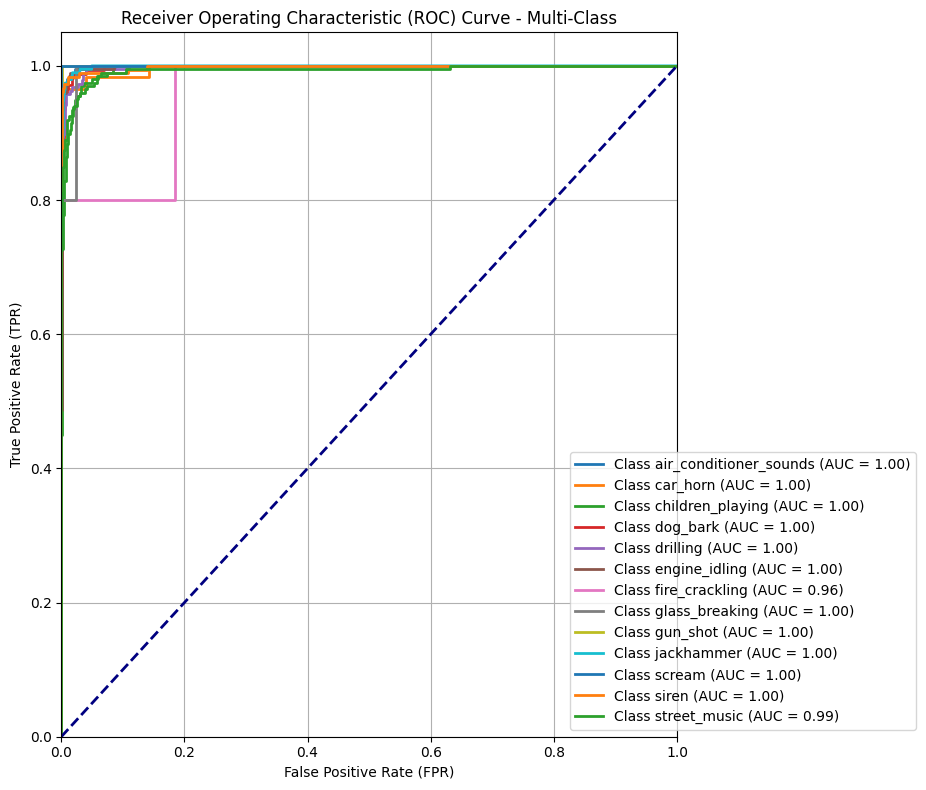

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# ==========================================
# 1. Predictions & Classification Report
# ==========================================
# Get model probability predictions
y_pred_probs = model.predict(X_test)
# Convert probabilities to class indices
y_pred = np.argmax(y_pred_probs, axis=1)

# Get target class names from the label encoder
class_names = [str(cls) for cls in label_encoder.classes_]

print("\n================ Classification Report ================")
print(classification_report(y_test, y_pred, target_names=class_names))


# ==========================================
# 2. Confusion Matrix & Percentage Confusion Matrix
# ==========================================
cm = confusion_matrix(y_test, y_pred)
# Calculate percentages by dividing each row by its sum
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(20, 8))

# Plot Raw Confusion Matrix
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Counts)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Plot Percentage Confusion Matrix
plt.subplot(1, 2, 2)
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Percentages %)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()
plt.show()


# ==========================================
# 3. Accuracy and Loss Curves
# ==========================================
plt.figure(figsize=(14, 5))

# Plot Training & Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue', lw=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', lw=2)
plt.title('Model Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Training & Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue', lw=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', lw=2)
plt.title('Model Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# ==========================================
# 4. Multi-class ROC Curve
# ==========================================
# Binarize labels for multi-class ROC calculation
y_test_binarized = label_binarize(y_test, classes=np.arange(13))

plt.figure(figsize=(10, 8))

# Compute ROC curve and ROC area for each of the 13 classes
for i in range(13):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class {class_names[i]} (AUC = {roc_auc:.2f})')

# Plot the baseline diagonal random choice line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('Receiver Operating Characteristic (ROC) Curve - Multi-Class')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc="lower right", bbox_to_anchor=(1.4, 0.0)) # Pushes legend outside if it crowds the plot
plt.grid(True)
plt.tight_layout()
plt.show()

**LSTM**

In [ ]:
import os
import librosa
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ==========================================
# 1. Preprocessing and Feature Extraction
# ==========================================
def preprocess_and_extract_features(file_path, target_sr=22050, duration=3):
    # Load audio with resampling
    y, sr = librosa.load(file_path, sr=target_sr)

    # Noise/Silence Removal
    y, _ = librosa.effects.trim(y, top_db=25)

    # Segmentation / Padding (Fixed to 3 seconds)
    target_length = target_sr * duration
    if len(y) > target_length:
        y = y[:target_length]
    else:
        y = np.pad(y, (0, max(0, target_length - len(y))), 'constant')

    # Audio amplitude normalization
    y = librosa.util.normalize(y)

    # High-resolution Mel-Spectrogram (128 bands)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, n_fft=2048, hop_length=512)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

    # Compute Delta and Delta-Delta features
    delta_mel = librosa.feature.delta(mel_spec_db)
    delta2_mel = librosa.feature.delta(mel_spec_db, order=2)

    # Stack features to create 3 channels (Shape: 128, time_frames, 3)
    features = np.stack([mel_spec_db, delta_mel, delta2_mel], axis=-1)

    return features

# ==========================================
# 2. Dataset Loading and Preparation
# ==========================================
DATASET_PATH = "/kaggle/input/datasets/sabrinashanta12/audio-data-set/audio"  # Replace with your actual folder path
X = []
y = []

print("--- Feature Extraction Started (This may take some time) ---")
for class_label in os.listdir(DATASET_PATH):
    class_dir = os.path.join(DATASET_PATH, class_label)
    if os.path.isdir(class_dir):
        print(f"Processing class: {class_label}")
        for file_name in os.listdir(class_dir):
            if file_name.lower().endswith(('.wav', '.mp3', '.m4a', '.flac')):
                file_path = os.path.join(class_dir, file_name)
                try:
                    features = preprocess_and_extract_features(file_path)
                    X.append(features)
                    y.append(class_label)
                except Exception as e:
                    print(f"Error processing {file_name}: {e}")

X = np.array(X, dtype=np.float32)
y = np.array(y)

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split dataset (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Global Standardization (Mean-Std Normalization)
mean = np.mean(X_train)
std = np.std(X_train)

X_train = (X_train - mean) / (std + 1e-7)
X_test = (X_test - mean) / (std + 1e-7)

print(f"\nTrain Shape: {X_train.shape}, Test Shape: {X_test.shape}")
print("--- Data Preparation Completed Successfully! ---")

--- Feature Extraction Started (This may take some time) ---
Processing class: jackhammer
Processing class: air_conditioner_sounds
Processing class: fire_crackling
Processing class: drilling
Processing class: glass_breaking
Processing class: children_playing
Processing class: scream
Processing class: gun_shot
Processing class: street_music
Processing class: engine_idling
Processing class: dog_bark
Processing class: siren
Processing class: car_horn

Train Shape: (7822, 128, 130, 3), Test Shape: (1956, 128, 130, 3)
--- Data Preparation Completed Successfully! ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 130, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128, 130, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 65, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64, 65, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 32, 2048)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 32, 256)        │     2,229,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 13)             │         1,677 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,432,077 (9.28 MB)

 Trainable params: 2,431,629 (9.28 MB)

 Non-trainable params: 448 (1.75 KB)

--- Starting Model Training ---
Epoch 1/80


E0000 00:00:1781433424.079901      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_5_1/dropout_9_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


123/123 ━━━━━━━━━━━━━━━━━━━━ 63s 386ms/step - accuracy: 0.2853 - loss: 2.6135 - val_accuracy: 0.2229 - val_loss: 2.3871 - learning_rate: 0.0010
Epoch 2/80
123/123 ━━━━━━━━━━━━━━━━━━━━ 45s 363ms/step - accuracy: 0.3765 - loss: 2.0722 - val_accuracy: 0.1524 - val_loss: 2.7368 - learning_rate: 0.0010
Epoch 3/80
123/123 ━━━━━━━━━━━━━━━━━━━━ 45s 365ms/step - accuracy: 0.4500 - loss: 1.7825 - val_accuracy: 0.2428 - val_loss: 2.6482 - learning_rate: 0.0010
Epoch 4/80
123/123 ━━━━━━━━━━━━━━━━━━━━ 46s 372ms/step - accuracy: 0.5073 - loss: 1.5948 - val_accuracy: 0.3742 - val_loss: 2.1089 - learning_rate: 0.0010
Epoch 5/80
123/123 ━━━━━━━━━━━━━━━━━━━━ 46s 371ms/step - accuracy: 0.5730 - loss: 1.3969 - val_accuracy: 0.3737 - val_loss: 2.2272 - learning_rate: 0.0010
Epoch 6/80
123/123 ━━━━━━━━━━━━━━━━━━━━ 46s 371ms/step - accuracy: 0.6185 - loss: 1.2549 - val_accuracy: 0.3323 - val_loss: 2.6637 - learning_rate: 0.0010
Epoch 7/80
123/123 ━━━━━━━━━━━━━━━━━━━━ 46s 374ms/step - accuracy: 0.6714 - loss:

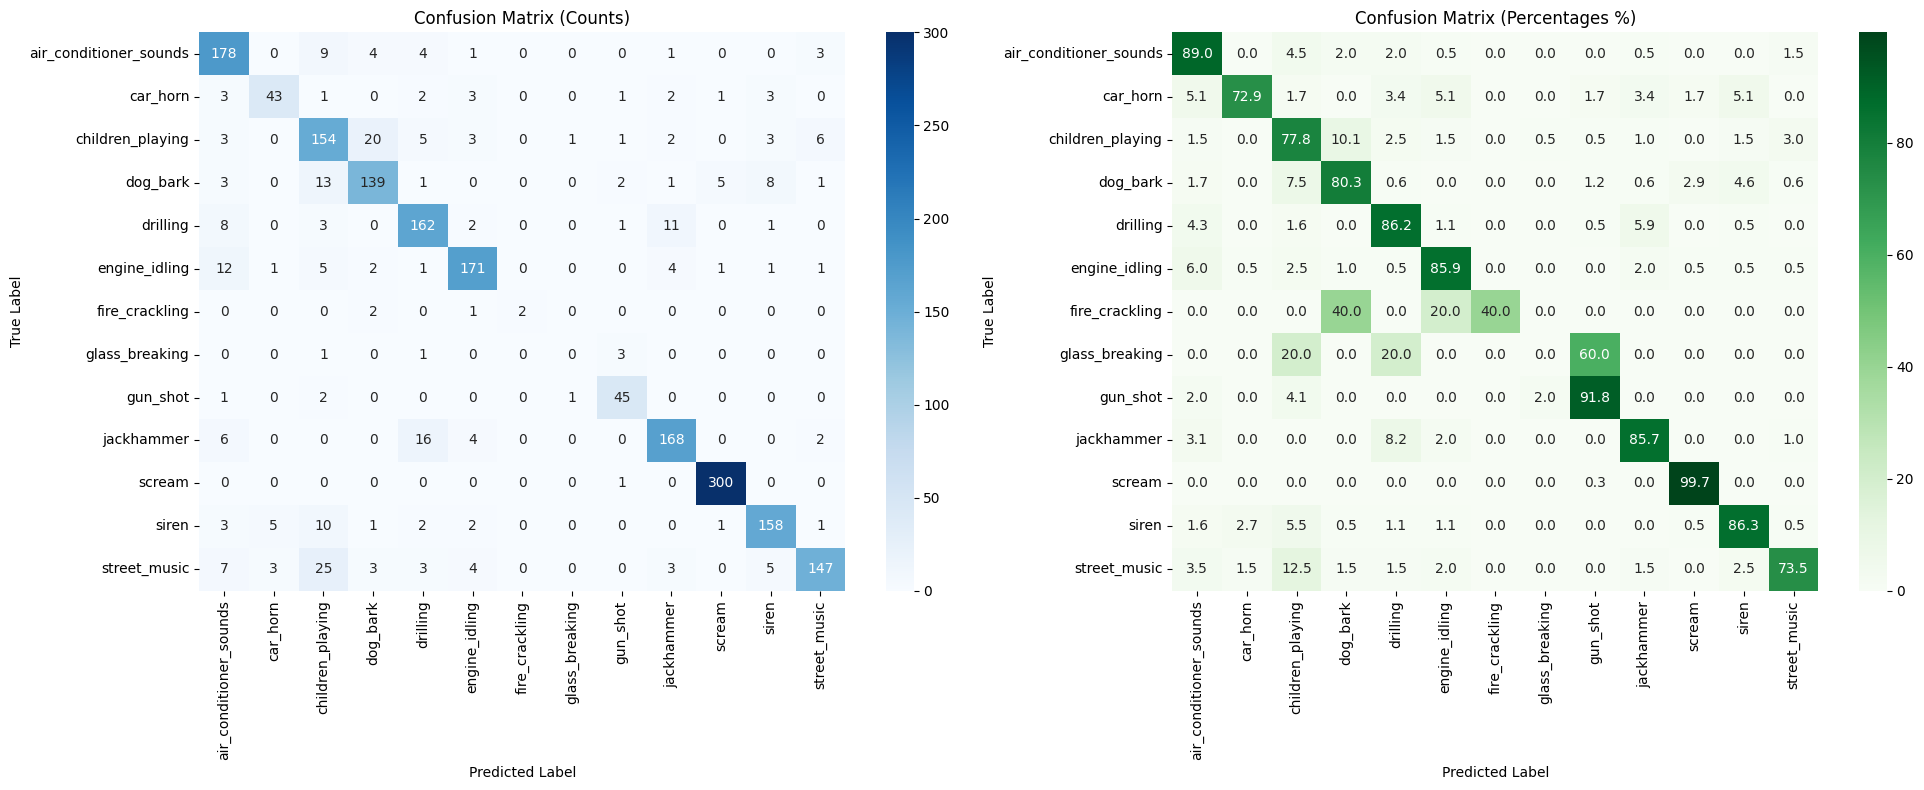

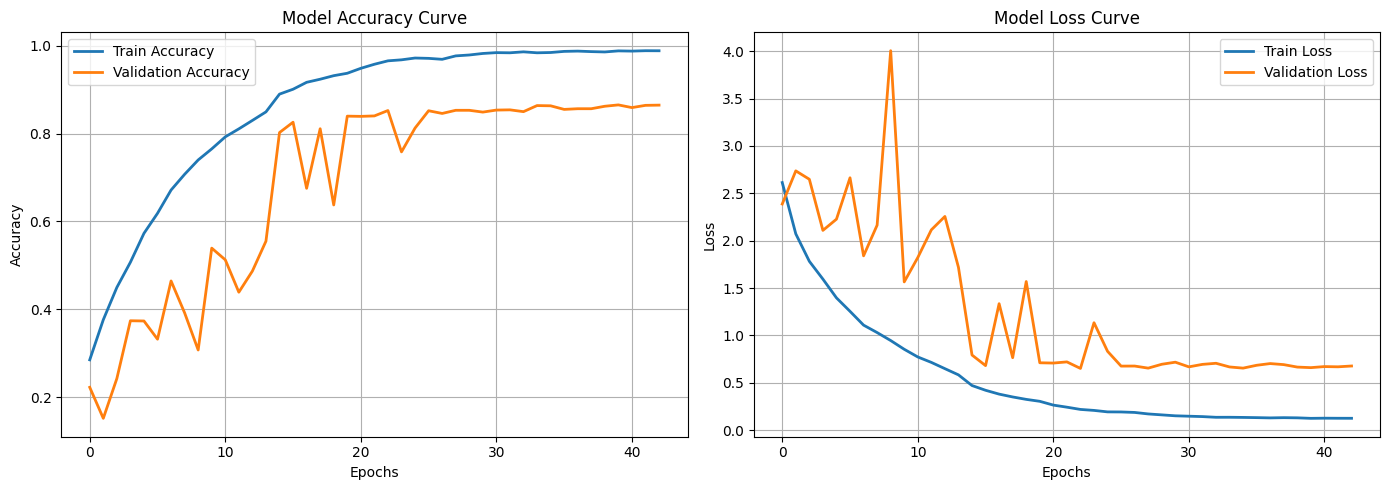

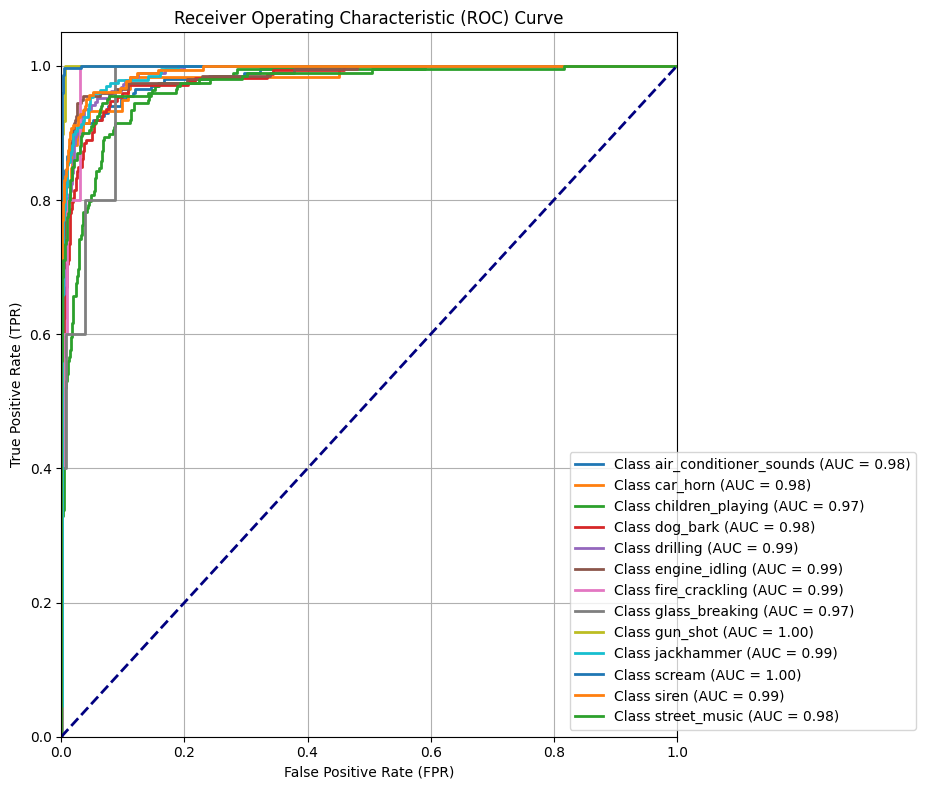

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# ==========================================
# 3. Regularized CRNN Model Architecture
# ==========================================
def create_regularized_crmn(input_shape, num_classes):
    model = models.Sequential()

    # CNN Block 1 with L2 Regularization
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=l2(0.001), input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.3))

    # CNN Block 2
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=l2(0.001)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.3))

    # Reshaping 4D tensor to 3D for LSTM layer input
    model.add(layers.Reshape(target_shape=(model.output_shape[2], model.output_shape[1] * model.output_shape[3])))

    # Bidirectional LSTM Layers with Recurrent Dropout
    model.add(layers.Bidirectional(layers.LSTM(128, return_sequences=True, recurrent_dropout=0.2)))
    model.add(layers.Dropout(0.4))

    model.add(layers.Bidirectional(layers.LSTM(64, return_sequences=False, recurrent_dropout=0.2)))
    model.add(layers.Dropout(0.4))

    # Dense Classification Layers
    model.add(layers.Dense(128, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))

    # Output Layer (13 Classes)
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

# Build and Compile the model
input_shape = X_train.shape[1:]  # Taken from Part 1 output
model = create_regularized_crmn(input_shape, num_classes=13)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# ==========================================
# 4. Model Training
# ==========================================
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=0.00001, verbose=1)
]

print("--- Starting Model Training ---")
history = model.fit(
    X_train, y_train,
    epochs=80,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=callbacks
)

# ==========================================
# 5. Full Evaluation & Visualizations
# ==========================================
# Get Predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
class_names = [str(cls) for cls in label_encoder.classes_]

# A. Classification Report
print("\n================ Classification Report ================")
print(classification_report(y_test, y_pred, target_names=class_names))

# B. Confusion Matrices
cm = confusion_matrix(y_test, y_pred)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Counts)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.subplot(1, 2, 2)
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Percentages %)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# C. Loss & Accuracy Curves
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', lw=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', lw=2)
plt.title('Model Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', lw=2)
plt.plot(history.history['val_loss'], label='Validation Loss', lw=2)
plt.title('Model Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# D. Multi-class ROC Curve
y_test_binarized = label_binarize(y_test, classes=np.arange(13))
plt.figure(figsize=(10, 8))
for i in range(13):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class {class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc="lower right", bbox_to_anchor=(1.4, 0.0))
plt.grid(True)
plt.tight_layout()
plt.show()